In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from skimage.metrics import peak_signal_noise_ratio
import os
import random

from olimp.dataset.olimp import olimp
from olimp.dataset import read_img_path

/home/user/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
IMG_SIZE      = 512
SIGMA         = 0.01
TRAIN_RATIO   = 0.85
BATCH_SIZE    = 2
NUM_EPOCHS    =45
LR            = 1e-4
LAMBDA_K      = 12          # вес supervised-лосса для K
LAMBDA_PHYS   = 2.0          # вес физического лосса
DEVICE        = torch.device("cuda:0")
SAVE_PATH     = "best_model_17KF.pt"
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [3]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print(f"Используемое устройство: {DEVICE}")

Используемое устройство: cuda:0


In [4]:
# %% [code]
CATEGORIES = [
    'abstracts and textures', 'abstracts and textures/abstract art',
    'abstracts and textures/backgrounds and patterns',
    'abstracts and textures/colorful abstracts',
    'abstracts and textures/geometric shapes',
    'abstracts and textures/neon abstracts', 'abstracts and textures/textures',
    'animals', 'animals/birds', 'animals/farm animals',
    'animals/insects and spiders', 'animals/marine life', 'animals/pets',
    'animals/wild animals', 'art and culture',
    'art and culture/cartoon and comics',
    'art and culture/crafts and handicrafts',
    'art and culture/dance and theater performances',
    'art and culture/music concerts and instruments',
    'art and culture/painting and frescoes',
    'art and culture/sculpture and bas-reliefs', 'food and drinks',
    'food and drinks/desserts and bakery', 'food and drinks/dishes',
    'food and drinks/drinks',
    'food and drinks/food products on store shelves',
    'food and drinks/fruits and vegetables', 'food and drinks/street food',
    'interiors', 'interiors/gyms and pools', 'interiors/living spaces',
    'interiors/museums and galleries', 'interiors/offices',
    'interiors/restaurants and cafes',
    'interiors/shopping centers and stores', 'nature', 'nature/beaches',
    'nature/deserts', 'nature/fields and meadows', 'nature/forest',
    'nature/mountains', 'nature/water bodies', 'objects and items',
    'objects and items/books and stationery',
    'objects and items/clothing and accessories',
    'objects and items/electronics and gadgets',
    'objects and items/furniture and decor',
    'objects and items/tools and equipment',
    'objects and items/toys and games', 'portraits and people',
    'portraits and people/athletes and dancers',
    'portraits and people/crowds and demonstrations',
    'portraits and people/group photos',
    'portraits and people/individual portraits',
    'portraits and people/models on runway',
    'portraits and people/workers in their workplaces',
    'sports and active leisure',
    'sports and active leisure/cycling and rollerblading',
    'sports and active leisure/extreme sports',
    'sports and active leisure/individual sports',
    'sports and active leisure/martial arts',
    'sports and active leisure/team sports',
    'sports and active leisure/tourism and hikes', 'text and pictogram',
    'text and pictogram/billboard text', 'text and pictogram/blueprints',
    'text and pictogram/caricatures and pencil drawing',
    'text and pictogram/text documents', 'text and pictogram/traffic signs',
    'urban scenes', 'urban scenes/architecture',
    'urban scenes/city at night', 'urban scenes/graffiti and street art',
    'urban scenes/parks and squares', 'urban scenes/streets and avenues',
    'urban scenes/transport',
]

all_paths = []
for cat in CATEGORIES:
    try:
        ds = olimp(categories={cat})
        paths = ds[cat]
        all_paths.extend(paths)
    except Exception as e:
        print(f"  {cat}: пропущено ({e})")

rng = np.random.default_rng(42)
rng.shuffle(all_paths)
all_paths = all_paths[:2000]   # ограничим для скорости
print(f"\nЗагружено изображений: {len(all_paths)}")

n_train = int(TRAIN_RATIO * len(all_paths))
train_paths = all_paths[:n_train]
val_paths   = all_paths[n_train:]
print(f"Train: {len(train_paths)} | Val: {len(val_paths)}")


/home/user/.local/lib/python3.10/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')


Загружено изображений: 2000
Train: 1700 | Val: 300


In [5]:
# ## 2. Вспомогательные функции


def load_o_f(img_path):
    """
    Загружает изображение и возвращает каналы o и f.
    o – яркостный канал (clear)
    f – "сплошной фильтр", например, красный канал, затемнённый
    """
    img = read_img_path(img_path)
    img = np.array(img, dtype=np.float32) / 255.0          # [C, H, W]
    img = np.transpose(img, (1, 2, 0))                     # [H, W, C]
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    if img.ndim == 2:
        img = np.stack([img, img, img], axis=-1)
    elif img.shape[2] == 1:
        img = np.concatenate([img, img, img], axis=-1)

    # o – яркость (clear)
    o = 0.299 * img[:,:,0] + 0.587 * img[:,:,1] + 0.114 * img[:,:,2]
    o = o.astype(np.float32)

    # f – "фильтр", например, красный канал с пониженной яркостью
    f = img[:,:,0].astype(np.float32) * 0.7
    return o, f

In [6]:
from scipy.ndimage import gaussian_filter

_cfg_rng = np.random.default_rng(0)

def stripe_filter_controlled(h, w, T0=12, angle_deg=0, strength=0.5,
                             warp_base=10, noise_sigma=0.03, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    y = np.arange(h); x = np.arange(w)
    X, Y = np.meshgrid(x, y)
    theta = np.deg2rad(angle_deg)
    U = -X * np.sin(theta) + Y * np.cos(theta)
    phase_reg = U / T0
    noise_warp = rng.standard_normal((h, w))
    noise_warp = gaussian_filter(noise_warp, sigma=(10, 30))
    d = (warp_base * strength) * noise_warp
    phase_warp = (U + d) / T0
    mask = rng.standard_normal((h, 1))
    mask = gaussian_filter(mask, sigma=(30, 0))
    mask = (mask - mask.min()) / (mask.max() - mask.min())
    mask = strength * mask
    mask = np.repeat(mask, w, axis=1)
    phase = (1 - mask) * phase_reg + mask * phase_warp
    base = np.sin(2 * np.pi * phase)
    drop_strength = 0.6 * strength
    drop = 1 - drop_strength * mask
    filt = base * drop
    filt += noise_sigma * rng.standard_normal((h, w))
    filt = (filt - filt.min()) / (filt.max() - filt.min())
    return filt.astype(np.float32)

# Конфигурации масок
stripe_h_configs = [{"type": "h", "width": float(w)} for w in _cfg_rng.uniform(4, 200, 1500)]
stripe_d_configs = [{"type": "d", "width": float(w), "angle": float(a)}
                    for w, a in zip(_cfg_rng.uniform(6, 180, 2000),
                                    _cfg_rng.uniform(0, 180, 2000))]
sin_configs = [{"type": "s", "freq": float(f), "angle": float(a), "phase": float(p)}
               for f, a, p in zip(_cfg_rng.uniform(1/120, 1/8, 1000),
                                  _cfg_rng.uniform(0, 180, 1000),
                                  _cfg_rng.uniform(0, 2*np.pi, 1000))]
wavy_controlled_configs = []
for _ in range(3000):
    T0 = _cfg_rng.uniform(8, 30)
    angle = _cfg_rng.uniform(-3, 3)
    strength = _cfg_rng.uniform(0.2, 0.9)
    warp_base = _cfg_rng.uniform(5, 20)
    noise_sigma = _cfg_rng.uniform(0.0, 0.05)
    wavy_controlled_configs.append({
        "type": "wavy_controlled",
        "T0": float(T0),
        "angle": float(angle),
        "strength": float(strength),
        "warp_base": float(warp_base),
        "noise_sigma": float(noise_sigma),
    })

ALL_CONFIGS = stripe_h_configs + stripe_d_configs + sin_configs + wavy_controlled_configs
print(f"Всего конфигураций масок: {len(ALL_CONFIGS)}")


Всего конфигураций масок: 7500


In [7]:
def make_mask(h: int, w: int, config: dict, rng: np.random.Generator = None) -> np.ndarray:
    if rng is None:
        rng = np.random.default_rng()
    if config["type"] == "h":
        sw = max(1.0, config["width"])
        y_idx = np.arange(h, dtype=np.float32)
        K = 0.5 + 0.5 * np.cos(2 * np.pi * y_idx / sw)
        return K[:, None] * np.ones((1, w), dtype=np.float32)
    elif config["type"] == "d":
        sw = max(1.0, config["width"])
        angle = np.radians(config["angle"])
        xs = np.arange(w, dtype=np.float32)[None, :]
        ys = np.arange(h, dtype=np.float32)[:, None]
        dist = xs * np.cos(angle) + ys * np.sin(angle)
        K = 0.5 + 0.5 * np.cos(2 * np.pi * dist / sw)
        return K.astype(np.float32)
    elif config["type"] == "wavy_controlled":
        T0 = config.get("T0", 20.0)
        angle = config.get("angle", 0.0)
        strength = config.get("strength", 0.5)
        warp_base = config.get("warp_base", 10.0)
        noise_sigma = config.get("noise_sigma", 0.03)
        return stripe_filter_controlled(
            h, w, T0=T0, angle_deg=angle, strength=strength,
            warp_base=warp_base, noise_sigma=noise_sigma, rng=rng
        )
    elif config["type"] == "s":
        freq = config["freq"]
        angle = np.radians(config["angle"])
        phase = config["phase"]
        a = 2 * np.pi * freq * np.cos(angle)
        b = 2 * np.pi * freq * np.sin(angle)
        xs = np.arange(w, dtype=np.float32)[None, :]
        ys = np.arange(h, dtype=np.float32)[:, None]
        return ((np.sin(a * xs + b * ys + phase) + 1) / 2).astype(np.float32)
    else:
        raise ValueError(f"Unknown mask type: {config['type']}")


In [8]:
# ## 3. Физическая модель с обучаемыми параметрами


class PhysicsModel(nn.Module):
    def __init__(self, init_vals=None):
        super().__init__()
        if init_vals is None:
            init_vals = {
                'a': -0.337624, 'b': 1.638787, 'c': 1.722659,
                'd': -2.183167, 'e': 0.001907,
                'so_x': -1.146426, 'so_y': -0.348294,
                'sf_x': -1.530425, 'sf_y': -0.447357,
            }
        self.a = nn.Parameter(torch.tensor(init_vals['a'], dtype=torch.float32))
        self.b = nn.Parameter(torch.tensor(init_vals['b'], dtype=torch.float32))
        self.c = nn.Parameter(torch.tensor(init_vals['c'], dtype=torch.float32))
        self.d = nn.Parameter(torch.tensor(init_vals['d'], dtype=torch.float32))
        self.e = nn.Parameter(torch.tensor(init_vals['e'], dtype=torch.float32))
        self.so_x = nn.Parameter(torch.tensor(init_vals['so_x'], dtype=torch.float32))
        self.so_y = nn.Parameter(torch.tensor(init_vals['so_y'], dtype=torch.float32))
        self.sf_x = nn.Parameter(torch.tensor(init_vals['sf_x'], dtype=torch.float32))
        self.sf_y = nn.Parameter(torch.tensor(init_vals['sf_y'], dtype=torch.float32))

    def shift(self, x, dx, dy):
        B, C, H, W = x.shape
        device = x.device
        # Создаём сетку на том же устройстве, что и x
        y, x_coords = torch.meshgrid(
            torch.linspace(-1, 1, H, device=device),
            torch.linspace(-1, 1, W, device=device),
            indexing='ij'
        )
        grid = torch.stack([x_coords, y], dim=-1).unsqueeze(0).repeat(B, 1, 1, 1)
        dx_norm = dx / (W / 2.0)
        dy_norm = dy / (H / 2.0)
        grid = grid + torch.tensor([dx_norm, dy_norm], device=device).view(1,1,1,2)
        return F.grid_sample(x, grid, mode='bilinear', padding_mode='border', align_corners=False)

    def forward(self, o, f, g):
        o_shifted = self.shift(o, self.so_x, self.so_y)
        f_shifted = self.shift(f, self.sf_x, self.sf_y)
        term1 = self.a * o_shifted
        term2 = self.b * o_shifted * g
        term3 = self.c * f_shifted
        term4 = self.d * f_shifted * g
        return term1 + term2 + term3 + term4 + self.e



In [9]:
class PhysicsStripeDataset(Dataset):
    def __init__(self, paths, configs, physics_model=None, augment=False, use_true_physics=True, device='cuda'):
        self.paths = paths
        self.configs = configs
        self.physics_model = physics_model
        self.augment = augment
        self.use_true_physics = use_true_physics
        self.device = device
        self._cfg_rng = np.random.default_rng(1337)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        o_np, f_np = load_o_f(self.paths[idx])          # [H, W] на CPU
        H, W = o_np.shape

        cfg = self.configs[self._cfg_rng.integers(len(self.configs))]
        g_np = make_mask(H, W, cfg)                     # [H, W] на CPU

        # Аугментации (на CPU)
        if self.augment:
            if self._cfg_rng.random() > 0.5:
                o_np = np.fliplr(o_np).copy()
                f_np = np.fliplr(f_np).copy()
                g_np = np.fliplr(g_np).copy()
            if self._cfg_rng.random() > 0.5:
                o_np = np.flipud(o_np).copy()
                f_np = np.flipud(f_np).copy()
                g_np = np.flipud(g_np).copy()
            if self._cfg_rng.random() > 0.5:
                k = self._cfg_rng.integers(0, 4)
                if k:
                    o_np = np.rot90(o_np, k).copy()
                    f_np = np.rot90(f_np, k).copy()
                    g_np = np.rot90(g_np, k).copy()

        # Переносим на GPU
        o_t = torch.from_numpy(o_np).float().unsqueeze(0).to(self.device)
        f_t = torch.from_numpy(f_np).float().unsqueeze(0).to(self.device)
        g_t = torch.from_numpy(g_np).float().unsqueeze(0).to(self.device)

        # Генерация P с помощью физической модели
        if self.physics_model is not None and self.use_true_physics:
            with torch.no_grad():
                # Модель уже на GPU, входные тензоры тоже на GPU
                og_t = self.physics_model(o_t.unsqueeze(0), f_t.unsqueeze(0), g_t.unsqueeze(0)).squeeze(0)
        else:
            # Fallback
            og_t = g_t * o_t**0.7 + (1 - g_t) * f_t**2

        # Добавляем шум
        noise = torch.randn_like(og_t) * SIGMA
        og_t = torch.clamp(og_t + noise, 0.0, 1.0)

        return {
            "P": og_t.cpu(),
            "K": g_t.cpu(),
            "o": o_t.cpu(),
            "f": f_t.cpu(),
            "weight": 1.0,
            "is_real": False,
        }

In [10]:
from scipy.signal import find_peaks
from scipy.interpolate import interp1d

def upsample_height_torch(x: torch.Tensor, scale_h: int = 8) -> torch.Tensor:
    assert x.ndim == 4 and x.shape[0] == 1 and x.shape[1] == 1
    _, _, h, w = x.shape
    return F.interpolate(x, size=(h * scale_h, w), mode='bilinear', align_corners=False)

def downsample_height_torch(x: torch.Tensor, target_h: int, target_w: int) -> torch.Tensor:
    return F.interpolate(x, size=(target_h, target_w), mode='bilinear', align_corners=False)

def interp_1d_with_fill(y_sparse: np.ndarray, mask: np.ndarray) -> np.ndarray:
    h = len(y_sparse)
    x = np.arange(h, dtype=np.float32)
    x_known = x[mask]
    y_known = y_sparse[mask]
    if len(x_known) == 0:
        return np.zeros_like(y_sparse, dtype=np.float32)
    if len(x_known) == 1:
        return np.full_like(y_sparse, y_known[0], dtype=np.float32)
    kind = "cubic" if len(x_known) >= 4 else "linear"
    f = interp1d(x_known, y_known, kind=kind, bounds_error=False,
                 fill_value=(y_known[0], y_known[-1]), assume_sorted=True)
    return f(x).astype(np.float32)

def reconstruct_u_f_from_extrema(P: torch.Tensor, scale_h: int = 8, distance: int = 4):
    device = P.device
    _, _, h, w = P.shape
    P_up = upsample_height_torch(P, scale_h)
    P_up_np = P_up.squeeze().detach().cpu().numpy().astype(np.float32)
    h_up, w_up = P_up_np.shape

    U_sparse = np.zeros((h_up, w_up), dtype=np.float32)
    F_sparse = np.zeros((h_up, w_up), dtype=np.float32)
    U_mask = np.zeros((h_up, w_up), dtype=bool)
    F_mask = np.zeros((h_up, w_up), dtype=bool)

    for j in range(w_up):
        col = P_up_np[:, j]
        peaks, _ = find_peaks(col, distance=distance)
        valleys, _ = find_peaks(-col, distance=distance)
        if len(peaks) == 0:
            peaks = np.array([int(np.argmax(col))], dtype=np.int32)
        if len(valleys) == 0:
            valleys = np.array([int(np.argmin(col))], dtype=np.int32)
        U_sparse[peaks, j] = col[peaks]
        U_mask[peaks, j] = True
        F_sparse[valleys, j] = col[valleys]
        F_mask[valleys, j] = True

    U_up = np.zeros_like(U_sparse, dtype=np.float32)
    F_up = np.zeros_like(F_sparse, dtype=np.float32)
    for j in range(w_up):
        U_up[:, j] = interp_1d_with_fill(U_sparse[:, j], U_mask[:, j])
        F_up[:, j] = interp_1d_with_fill(F_sparse[:, j], F_mask[:, j])

    U_up_t = torch.from_numpy(U_up).unsqueeze(0).unsqueeze(0).float().to(device)
    F_up_t = torch.from_numpy(F_up).unsqueeze(0).unsqueeze(0).float().to(device)

    U = downsample_height_torch(U_up_t, target_h=h, target_w=w)
    Fch = downsample_height_torch(F_up_t, target_h=h, target_w=w)
    return U, Fch
from scipy.ndimage import median_filter, binary_closing, binary_opening
def compute_refined_K(p_np, scale_h=8, distance=2, device="cuda:0"):
     # Нормализация
    if p_np.max() > 1.0:
        p_np = p_np.astype(np.float32) / 65535.0

    # Получение U и F через экстремумы (как в исходной функции)
    p_t = torch.from_numpy(p_np).float().unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        U, F = reconstruct_u_f_from_extrema(p_t, scale_h=scale_h, distance=distance)
    U_np = U.squeeze().cpu().numpy()
    F_np = F.squeeze().cpu().numpy()

    # Вычисление K
    eps = 1e-6
    K = (p_np - F_np) / (U_np - F_np + eps)
    K = np.clip(K, 0.0, 1.0)

    # Постобработка: шумоподавление и морфология
    K = median_filter(K, size=3)
    K_bin = K > 0.5
    K_bin = binary_closing(K_bin, iterations=1)   # заполняет мелкие дырки
    K_bin = binary_opening(K_bin, iterations=1)   # удаляет мелкие выбросы
    K = K_bin.astype(np.float32)

    return K.astype(np.float32)
    

# Загружаем реальные файлы
REAL_FILES = ["lf.npy", "lf2.npy", "lf3.npy"]
DATA_DIR = Path(".")
REAL_SAMPLES = []  # список словарей с P и K

for fname in REAL_FILES:
    file_path = DATA_DIR / fname
    if not file_path.exists():
        print(f"Файл {file_path} не найден, пропускаем.")
        continue
    p_np = np.load(file_path)
    K_ref = compute_refined_K(p_np, device=DEVICE)
    # Ресайз при необходимости
    if p_np.shape != (IMG_SIZE, IMG_SIZE):
        p_np = cv2.resize(p_np, (IMG_SIZE, IMG_SIZE))
        K_ref = cv2.resize(K_ref, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    P_tensor = torch.from_numpy(p_np).float().unsqueeze(0)
    K_tensor = torch.from_numpy(K_ref).float().unsqueeze(0)
    REAL_SAMPLES.append({"P": P_tensor, "K": K_tensor})
    print(f"{fname} обработан, размер {p_np.shape}")

print(f"Загружено {len(REAL_SAMPLES)} реальных примеров.")

lf.npy обработан, размер (512, 512)
lf2.npy обработан, размер (512, 512)
lf3.npy обработан, размер (512, 512)
Загружено 3 реальных примеров.


In [11]:
# ## 5. Комбинированный датасет и сэмплер


class CombinedPhysicsDataset(Dataset):
    def __init__(self, synthetic_dataset, real_samples, real_weight=15.0, augment=True):
        self.synthetic = synthetic_dataset
        self.real_samples = real_samples
        self.real_weight = real_weight
        self.augment = augment
        self.syn_len = len(synthetic_dataset)
        self.real_len = len(real_samples)
        self._rng = np.random.default_rng(42)

    def __len__(self):
        return self.syn_len + self.real_len

    def __getitem__(self, idx):
        if idx < self.syn_len:
            data = self.synthetic[idx]
            data['weight'] = 1.0
            data['is_real'] = False
            return data
        else:
            real_idx = (idx - self.syn_len) % self.real_len
            item = self.real_samples[real_idx]
            # Реальные данные уже на GPU? Лучше хранить на CPU, чтобы DataLoader мог перенести.
            # Предположим, что они на CPU.
            P = item["P"].clone()  # [1, H, W]
            K = item["K"].clone()
            if self.augment:
                if self._rng.random() > 0.5:
                    P = torch.flip(P, dims=[2])
                    K = torch.flip(K, dims=[2])
                if self._rng.random() > 0.5:
                    P = torch.flip(P, dims=[1])
                    K = torch.flip(K, dims=[1])
                if self._rng.random() > 0.5:
                    k = self._rng.integers(0, 4)
                    if k:
                        P = torch.rot90(P, k, dims=[1, 2])
                        K = torch.rot90(K, k, dims=[1, 2])
            return {
                "P": P,
                "K": K,
                "o": torch.zeros_like(P),
                "f": torch.zeros_like(P),
                "weight": float(self.real_weight),
                "is_real": True,
            }

from torch.utils.data import Sampler

class MixedBatchSampler(Sampler):
    def __init__(self, dataset, batch_size, real_per_batch=2, drop_last=True):
        self.dataset = dataset
        self.batch_size = batch_size
        self.real_per_batch = real_per_batch
        self.syn_per_batch = batch_size - real_per_batch
        self.drop_last = drop_last
        self.syn_len = dataset.syn_len
        self.real_len = dataset.real_len

    def __iter__(self):
        syn_indices = np.random.permutation(self.syn_len)
        real_indices = self.syn_len + np.random.randint(0, self.real_len,
                            size=len(syn_indices)//self.syn_per_batch * self.real_per_batch + self.real_per_batch)
        syn_ptr = 0
        real_ptr = 0
        while syn_ptr + self.syn_per_batch <= len(syn_indices):
            batch = list(syn_indices[syn_ptr:syn_ptr+self.syn_per_batch])
            syn_ptr += self.syn_per_batch
            batch.extend(real_indices[real_ptr:real_ptr+self.real_per_batch])
            real_ptr += self.real_per_batch
            np.random.shuffle(batch)
            yield batch
        if not self.drop_last and syn_ptr < len(syn_indices):
            batch = list(syn_indices[syn_ptr:])
            while len(batch) < self.batch_size:
                batch.append(real_indices[real_ptr])
                real_ptr += 1
            yield batch

    def __len__(self):
        return self.syn_len // self.syn_per_batch
REAL_SAMPLES = [{"P": item["P"].cpu(), "K": item["K"].cpu()} for item in REAL_SAMPLES]

In [12]:
# ## 6. Архитектура U-Net (как раньше)

# %% [code]
class ResBlock(nn.Module):
    def __init__(self, ch, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(ch),
            nn.GELU(),
            nn.Dropout2d(dropout),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(ch),
        )
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        return F.gelu(x + self.dropout(self.net(x)))

class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, n_res=2, dropout=0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            *[ResBlock(out_ch, dropout) for _ in range(n_res)],
        )
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        x = self.conv(x)
        return self.pool(x), x

class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, n_res=2, dropout=0.1):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.conv = nn.Sequential(
            nn.Conv2d(out_ch + skip_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(min(8, out_ch), out_ch),
            nn.GELU(),
            *[ResBlock(out_ch, dropout) for _ in range(n_res)],
        )

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))

class KPredictor(nn.Module):
    def __init__(self, base_ch=32, dropout=0.15):
        super().__init__()
        self.d1 = DownBlock(1, base_ch, dropout=dropout)
        self.d2 = DownBlock(base_ch, base_ch*2, dropout=dropout)
        self.d3 = DownBlock(base_ch*2, base_ch*4, dropout=dropout)
        self.d4 = DownBlock(base_ch*4, base_ch*8, dropout=dropout)
        self.bot = nn.Sequential(ResBlock(base_ch*8, dropout), ResBlock(base_ch*8, dropout))
        self.u4 = UpBlock(base_ch*8, base_ch*8, base_ch*4, dropout=dropout)
        self.u3 = UpBlock(base_ch*4, base_ch*4, base_ch*2, dropout=dropout)
        self.u2 = UpBlock(base_ch*2, base_ch*2, base_ch, dropout=dropout)
        self.u1 = UpBlock(base_ch, base_ch, base_ch, dropout=dropout)
        self.head = nn.Sequential(
            nn.Conv2d(base_ch, base_ch//2, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(base_ch//2, 1, 1),
        )

    def forward(self, P):
        x, s1 = self.d1(P)
        x, s2 = self.d2(x)
        x, s3 = self.d3(x)
        x, s4 = self.d4(x)
        x = self.bot(x)
        x = self.u4(x, s4)
        x = self.u3(x, s3)
        x = self.u2(x, s2)
        x = self.u1(x, s1)
        return torch.sigmoid(self.head(x))



In [13]:
# ## 7. Функции потерь


def dice_loss(pred, target, smooth=1e-5):
    p = pred.view(-1)
    t = target.view(-1)
    intersection = (p * t).sum()
    return 1 - (2. * intersection + smooth) / (p.sum() + t.sum() + smooth)

def focal_loss(pred, target, gamma=2.0, alpha=0.5):
    pred = pred.clamp(1e-6, 1 - 1e-6)
    bce = F.binary_cross_entropy(pred, target, reduction='none')
    pt = torch.where(target > 0.5, pred, 1.0 - pred)
    return (alpha * (1.0 - pt) ** gamma * bce).mean()

def edge_alignment_loss(pred, target):
    def laplacian(x):
        kernel = torch.tensor([[0,1,0],[1,-4,1],[0,1,0]], dtype=x.dtype, device=x.device).view(1,1,3,3)
        return F.conv2d(x, kernel, padding=1)
    return F.l1_loss(laplacian(pred), laplacian(target))

def k_loss(K_hat, K_gt):
    l_dice = dice_loss(K_hat, K_gt)
    l_focal = focal_loss(K_hat, K_gt, gamma=2.0)
    l_edge = edge_alignment_loss(K_hat, K_gt)
    
    # Добавляем L1 между предсказанием и GT (чтобы напрямую тянуть значения)
    l_l1 = F.l1_loss(K_hat, K_gt)
    
    return l_dice + l_focal + l_edge + 2.0 * l_l1


In [14]:
# ## 8. Инициализация всего и обучение


# Инициализация физической модели
physics_model = PhysicsModel().to(DEVICE)

# Синтетический датасет (использует физическую модель для генерации P)
syn_train_ds = PhysicsStripeDataset(train_paths, ALL_CONFIGS, physics_model, augment=True, use_true_physics=True)
syn_val_ds   = PhysicsStripeDataset(val_paths,   ALL_CONFIGS, physics_model, augment=False, use_true_physics=True)

# Комбинированные датасеты
combined_train_ds = CombinedPhysicsDataset(syn_train_ds, REAL_SAMPLES, real_weight=25.0, augment=True)
combined_val_ds   = CombinedPhysicsDataset(syn_val_ds,   REAL_SAMPLES, real_weight=1.0,  augment=False)

# Сэмплер и DataLoader
batch_sampler = MixedBatchSampler(combined_train_ds, batch_size=BATCH_SIZE, real_per_batch=BATCH_SIZE // 2, drop_last=True)
train_dl = DataLoader(combined_train_ds, batch_sampler=batch_sampler, num_workers=0, pin_memory=False)
val_dl   = DataLoader(combined_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f"Train batches per epoch: {len(train_dl)}")
print(f"Val batches: {len(val_dl)}")



Train batches per epoch: 1700
Val batches: 152


In [15]:
# Модель U-Net
model = KPredictor(base_ch=32, dropout=0.1).to(DEVICE)

# Оптимизатор (объединяем параметры модели и физической модели)
optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(physics_model.parameters()),
    lr=LR, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

# Цикл обучения
history = {"train_loss": [], "val_loss": []}
best_val_loss = float("inf")

for epoch in range(1, NUM_EPOCHS+1):
    model.train()
    physics_model.train()
    train_loss = 0.0
    pbar = tqdm(train_dl, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Train]")
    for batch in pbar:
        P = batch['P'].to(DEVICE)
        K_gt = batch['K'].to(DEVICE)
        o = batch['o'].to(DEVICE)
        f = batch['f'].to(DEVICE)
        weight = batch['weight'].to(DEVICE).view(-1, 1, 1, 1)
        is_real = batch['is_real']

        # Предсказание маски
        K_hat = model(P)

        # Loss для K (взвешенный)
        loss_k = k_loss(K_hat, K_gt)
        # Для реальных примеров даём больший вес
        loss_k_weighted = (loss_k * weight).mean() if isinstance(loss_k, torch.Tensor) else loss_k * weight.mean()

        # Физический loss (только для синтетики, где есть o,f)
        mask_syn = ~is_real.to(DEVICE)
        if mask_syn.any():
            o_syn = o[mask_syn]
            f_syn = f[mask_syn]
            P_syn = P[mask_syn]
            K_hat_syn = K_hat[mask_syn]
            P_pred = physics_model(o_syn, f_syn, K_hat_syn)
            loss_phys = F.mse_loss(P_pred, P_syn)
        else:
            loss_phys = torch.tensor(0.0, device=DEVICE)

        total_loss = loss_k_weighted + LAMBDA_PHYS * loss_phys

        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        torch.nn.utils.clip_grad_norm_(physics_model.parameters(), 1.0)
        optimizer.step()

        train_loss += total_loss.item()
        pbar.set_postfix(loss=total_loss.item())

    avg_train_loss = train_loss / len(train_dl)
    history["train_loss"].append(avg_train_loss)

    # Валидация
    model.eval()
    physics_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(val_dl, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Val]", leave=False):
            P = batch['P'].to(DEVICE)
            K_gt = batch['K'].to(DEVICE)
            o = batch['o'].to(DEVICE)
            f = batch['f'].to(DEVICE)
            weight = batch['weight'].to(DEVICE).view(-1, 1, 1, 1)
            is_real = batch['is_real']

            K_hat = model(P)
            loss_k = k_loss(K_hat, K_gt)
            loss_k_weighted = (loss_k * weight).mean() if isinstance(loss_k, torch.Tensor) else loss_k * weight.mean()

            mask_syn = ~is_real.to(DEVICE)
            if mask_syn.any():
                o_syn = o[mask_syn]
                f_syn = f[mask_syn]
                P_syn = P[mask_syn]
                K_hat_syn = K_hat[mask_syn]
                P_pred = physics_model(o_syn, f_syn, K_hat_syn)
                loss_phys = F.mse_loss(P_pred, P_syn)
            else:
                loss_phys = torch.tensor(0.0, device=DEVICE)

            total_loss = loss_k_weighted + LAMBDA_PHYS * loss_phys
            val_loss += total_loss.item()

    avg_val_loss = val_loss / len(val_dl)
    history["val_loss"].append(avg_val_loss)

    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save({
            'model_state_dict': model.state_dict(),
            'physics_state_dict': physics_model.state_dict(),
        }, SAVE_PATH)
        print(f"  Сохранена лучшая модель (val_loss = {best_val_loss:.6f})")

    print(f"Epoch {epoch:03d} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

Epoch 1/45 [Train]:   0%|                              | 0/1700 [00:00<?, ?it/s]/home/user/.local/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,
Epoch 1/45 [Train]: 100%|████████| 1700/1700 [12:49<00:00,  2.21it/s, loss=10.3]
                                                                                

  Сохранена лучшая модель (val_loss = 1.327763)
Epoch 001 | Train Loss: 12.154197 | Val Loss: 1.327763 | LR: 1.00e-04


Epoch 2/45 [Train]: 100%|████████| 1700/1700 [12:37<00:00,  2.24it/s, loss=11.4]
                                                                                

  Сохранена лучшая модель (val_loss = 1.309915)
Epoch 002 | Train Loss: 10.952138 | Val Loss: 1.309915 | LR: 1.00e-04


Epoch 3/45 [Train]: 100%|████████| 1700/1700 [12:38<00:00,  2.24it/s, loss=9.88]
                                                                                

...

Epoch 043 | Train Loss: 3.486249 | Val Loss: 0.937469 | LR: 6.25e-06


Epoch 44/45 [Train]: 100%|███████| 1700/1700 [12:35<00:00,  2.25it/s, loss=2.51]
                                                                                

Epoch 044 | Train Loss: 3.495211 | Val Loss: 0.905149 | LR: 6.25e-06


Epoch 45/45 [Train]: 100%|██████████| 1700/1700 [12:38<00:00,  2.24it/s, loss=5]
                                                                                

Epoch 045 | Train Loss: 3.558517 | Val Loss: 0.842734 | LR: 6.25e-06


In [15]:
model = KPredictor(base_ch=32, dropout=0.1).to(DEVICE)


# ------------------------------------------------------------
# Шаг 2: Загрузка весов из файла
# ------------------------------------------------------------
SAVE_PATH = "best_model_17KF.pt"   # Убедитесь, что путь корректен
checkpoint = torch.load(SAVE_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
physics_model.load_state_dict(checkpoint['physics_state_dict'])
print("Веса модели и физической модели успешно загружены.")

Веса модели и физической модели успешно загружены.


In [16]:
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

# Возьмём несколько примеров из валидации
batch = next(iter(val_dl))
P = batch['P'][:4].to(DEVICE)
K_gt = batch['K'][:4].to(DEVICE)
o = batch['o'][:4].to(DEVICE)
f = batch['f'][:4].to(DEVICE)
is_real = batch['is_real'][:4]

with torch.no_grad():
    K_hat = model(P)
    P_pred = physics_model(o, f, K_hat) if not is_real[0] else torch.zeros_like(P)

P_np = P.cpu().numpy()[:, 0]
K_gt_np = K_gt.cpu().numpy()[:, 0]
K_hat_np = K_hat.cpu().numpy()[:, 0]
P_pred_np = P_pred.cpu().numpy()[:, 0].clip(0, 1)

# Расчёт метрик
psnr_K_list, ssim_K_list = [], []
psnr_P_list, ssim_P_list = [], []

for i in range(4):
    psnr_K = psnr(K_gt_np[i], K_hat_np[i], data_range=1.0)
    ssim_K = ssim(K_gt_np[i], K_hat_np[i], data_range=1.0)
    psnr_K_list.append(psnr_K)
    ssim_K_list.append(ssim_K)
    
    if not is_real[i]:
        psnr_P = psnr(P_np[i], P_pred_np[i], data_range=1.0)
        ssim_P = ssim(P_np[i], P_pred_np[i], data_range=1.0)
        psnr_P_list.append(psnr_P)
        ssim_P_list.append(ssim_P)

# Вывод средних метрик
print(f"Средние метрики по {len(psnr_K_list)} валидационным примерам:")
print(f"  Маска K: PSNR = {np.mean(psnr_K_list):.2f} дБ, SSIM = {np.mean(ssim_K_list):.4f}")
if psnr_P_list:
    print(f"  Реконструкция P: PSNR = {np.mean(psnr_P_list):.2f} дБ, SSIM = {np.mean(ssim_P_list):.4f}")

# Визуализация с метриками
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
base_titles = ["P (input)", "K GT", "K̂ predicted", "P̂ reconstructed"]
for i in range(4):
    imgs = [P_np[i], K_gt_np[i], K_hat_np[i], P_pred_np[i]]
    for j, img in enumerate(imgs):
        ax = axes[i, j]
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        
        # Формируем заголовок с метриками для предсказаний
        if j == 2:  # K̂
            title = f"K̂ predicted\nPSNR={psnr_K_list[i]:.1f}dB, SSIM={ssim_K_list[i]:.3f}"
        elif j == 3 and not is_real[i]:  # P̂
            title = f"P̂ reconstructed\nPSNR={psnr_P_list[i]:.1f}dB, SSIM={ssim_P_list[i]:.3f}"
        else:
            title = base_titles[j]
        
        if i == 0:
            ax.set_title(title, fontsize=10)
        ax.axis('off')
plt.tight_layout()
plt.show()

print("Обучение завершено. Параметры физической модели:")
print(f"a = {physics_model.a.item():.6f}")
print(f"b = {physics_model.b.item():.6f}")
print(f"c = {physics_model.c.item():.6f}")
print(f"d = {physics_model.d.item():.6f}")
print(f"e = {physics_model.e.item():.6f}")
print(f"so_x = {physics_model.so_x.item():.6f}, so_y = {physics_model.so_y.item():.6f}")
print(f"sf_x = {physics_model.sf_x.item():.6f}, sf_y = {physics_model.sf_y.item():.6f}")

/home/user/.local/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


IndexError: index 2 is out of bounds for axis 0 with size 2

In [17]:
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

# ... (после загрузки модели и получения предсказаний)

P_np = P.cpu().numpy()[:, 0]
K_gt_np = K_gt.cpu().numpy()[:, 0]
K_hat_np = K_hat.cpu().numpy()[:, 0]
P_pred_np = P_pred.cpu().numpy()[:, 0].clip(0, 1)

# Расчёт метрик для каждого примера и средних
psnr_K_list = []
ssim_K_list = []
psnr_P_list = []
ssim_P_list = []

for i in range(4):
    # Метрики для маски K
    psnr_K = psnr(K_gt_np[i], K_hat_np[i], data_range=1.0)
    ssim_K = ssim(K_gt_np[i], K_hat_np[i], data_range=1.0)
    psnr_K_list.append(psnr_K)
    ssim_K_list.append(ssim_K)
    
    # Метрики для реконструированного P (только для синтетики)
    if not batch['is_real'][i]:
        psnr_P = psnr(P_np[i], P_pred_np[i], data_range=1.0)
        ssim_P = ssim(P_np[i], P_pred_np[i], data_range=1.0)
        psnr_P_list.append(psnr_P)
        ssim_P_list.append(ssim_P)

# Средние значения
avg_psnr_K = np.mean(psnr_K_list)
avg_ssim_K = np.mean(ssim_K_list)
print(f"Средние метрики по {len(psnr_K_list)} примерам:")
print(f"  K: PSNR = {avg_psnr_K:.2f} dB, SSIM = {avg_ssim_K:.4f}")
if psnr_P_list:
    avg_psnr_P = np.mean(psnr_P_list)
    avg_ssim_P = np.mean(ssim_P_list)
    print(f"  P_recon: PSNR = {avg_psnr_P:.2f} dB, SSIM = {avg_ssim_P:.4f}")

# Визуализация с метриками на подписях
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
titles = ["P (input)", "K GT", "K̂ predicted", "P̂ reconstructed"]
for i in range(4):
    imgs = [P_np[i], K_gt_np[i], K_hat_np[i], P_pred_np[i]]
    for j, (img, ttl) in enumerate(zip(imgs, titles)):
        ax = axes[i, j]
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        # Добавляем метрики в подпись для K_pred и P_pred
        if j == 2:
            ttl = f"K̂ pred\nPSNR={psnr_K_list[i]:.1f}dB, SSIM={ssim_K_list[i]:.3f}"
        elif j == 3 and not batch['is_real'][i]:
            ttl = f"P̂ recon\nPSNR={psnr_P_list[i]:.1f}dB, SSIM={ssim_P_list[i]:.3f}"
        else:
            ttl = titles[j]
        if i == 0:
            ax.set_title(ttl, fontsize=10)
        ax.axis('off')
plt.tight_layout()
plt.show()

IndexError: index 2 is out of bounds for axis 0 with size 2

Изображение приведено к размеру 512x512


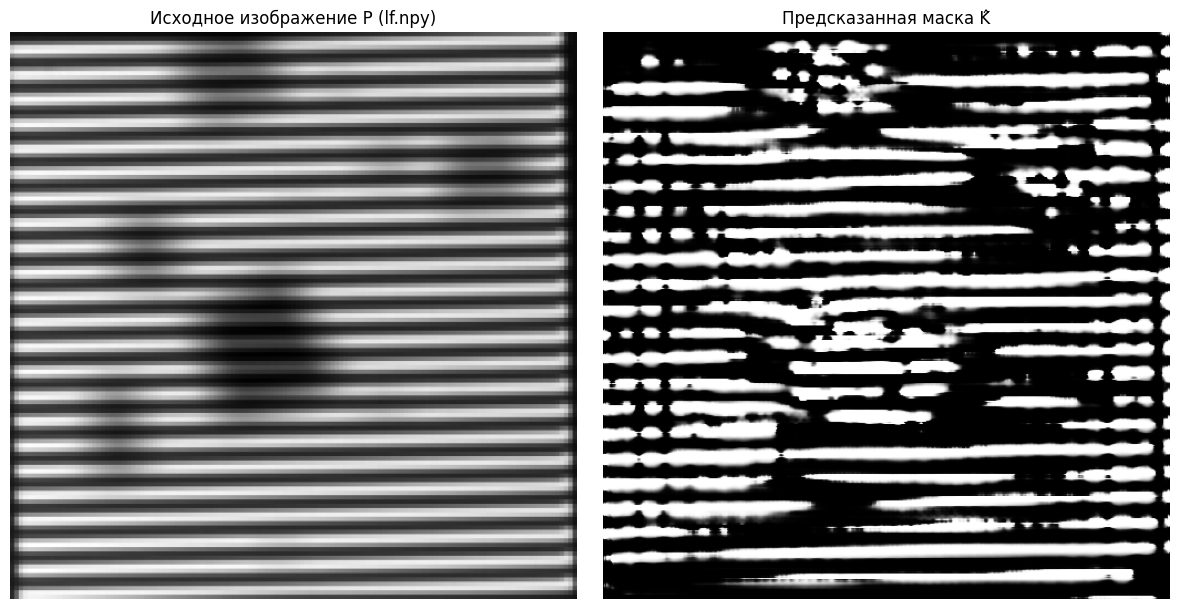

In [18]:
# Загрузка и подготовка данных
lf_path = "lf.npy"
if not Path(lf_path).exists():
    print(f"Файл {lf_path} не найден!")
else:
    # Загружаем и нормализуем
    p_np = np.load(lf_path)
    if p_np.max() > 1.0:
        p_np = p_np.astype(np.float32) / 65535.0  # или /255.0 в зависимости от данных
    else:
        p_np = p_np.astype(np.float32)
    
    # Ресайз до IMG_SIZE (если нужно)
    if p_np.shape != (IMG_SIZE, IMG_SIZE):
        p_np = cv2.resize(p_np, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        print(f"Изображение приведено к размеру {IMG_SIZE}x{IMG_SIZE}")
    
    # Преобразование в тензор [1, 1, H, W]
    P_tensor = torch.from_numpy(p_np).float().unsqueeze(0).unsqueeze(0).to(DEVICE)
    
    # Предсказание
    model.eval()
    with torch.no_grad():
        K_pred = model(P_tensor)
    
    K_pred_np = K_pred.squeeze().cpu().numpy()
    
    # Визуализация
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(p_np, cmap='gray')
    axes[0].set_title("Исходное изображение P (lf.npy)")
    axes[0].axis('off')
    
    axes[1].imshow(K_pred_np, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title("Предсказанная маска K̂")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

In [19]:
# 1. Загружаем чекпоинт, который был сохранён после основного обучения (эпоха 23 или лучший)
checkpoint = torch.load("best_model_17KF.pt", map_location=DEVICE)

# 2. Загружаем веса в модель (заменяем текущие)
model.load_state_dict(checkpoint['model_state_dict'])
physics_model.load_state_dict(checkpoint['physics_state_dict'])

# 3. Переводим в режим оценки
model.eval()
physics_model.eval()
print("Исходная модель загружена.")

Исходная модель загружена.


Исходная модель на lf.npy:
  PSNR = 1.77 dB
  SSIM = -0.1288


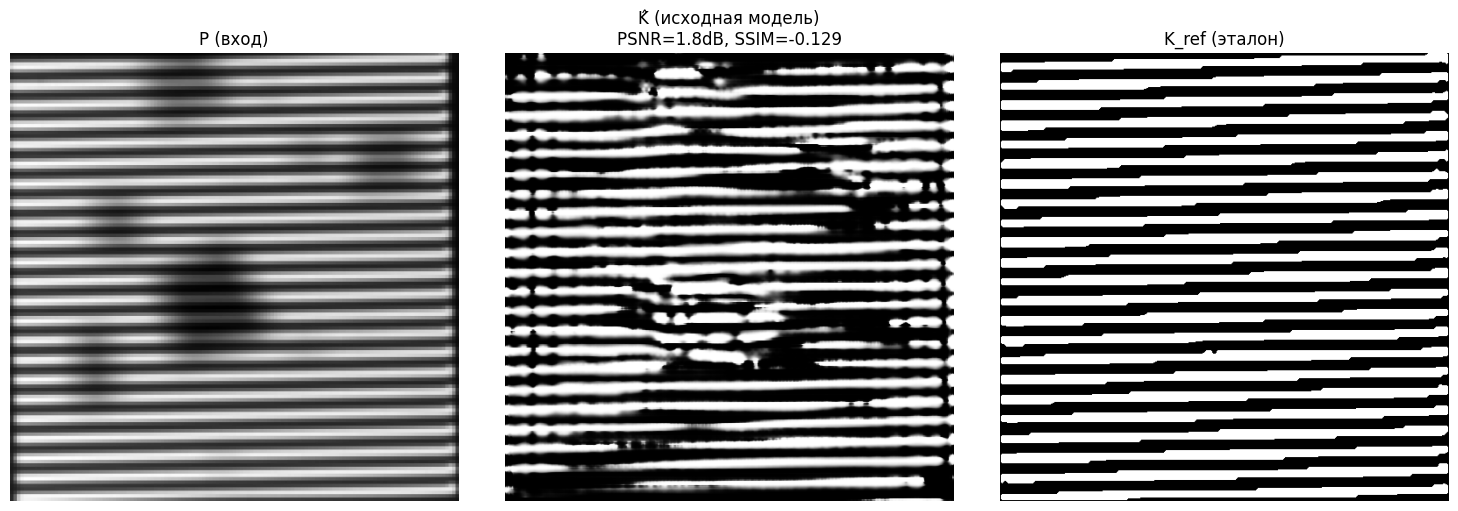

In [23]:
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim# Загружаем и подготавливаем реальный скан
p_np = np.load("lf.npy")
if p_np.max() > 1.0:
    p_np = p_np.astype(np.float32) / 65535.0

if p_np.shape != (IMG_SIZE, IMG_SIZE):
    p_np = cv2.resize(p_np, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

P_tensor = torch.from_numpy(p_np).float().unsqueeze(0).unsqueeze(0).to(DEVICE)

# Предсказание маски
with torch.no_grad():
    K_hat_tensor = model(P_tensor)
K_hat = K_hat_tensor.squeeze().cpu().numpy()

# Эталон K_ref (улучшенный)
K_ref = compute_refined_K(p_np, device=DEVICE)

# Метрики
psnr_val = peak_signal_noise_ratio(K_ref, K_hat, data_range=1.0)
ssim_val = ssim(K_ref, K_hat, data_range=1.0)
print(f"Исходная модель на lf.npy:")
print(f"  PSNR = {psnr_val:.2f} dB")
print(f"  SSIM = {ssim_val:.4f}")

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(p_np, cmap='gray')
axes[0].set_title("P (вход)")
axes[1].imshow(K_hat, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f"K̂ (исходная модель)\nPSNR={psnr_val:.1f}dB, SSIM={ssim_val:.3f}")
axes[2].imshow(K_ref, cmap='gray', vmin=0, vmax=1)
axes[2].set_title("K_ref (эталон)")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()